# Imports + Device

In [1]:
#Importing Libraries
from pathlib import Path #to handle filesystem paths in a platform-independent way
import torch #handles underlying tensor operations and model inference, provides GPU acceleration if available
#PIL (Pillow) is a library for opening, manipulating, and saving many different image file formats. Here it is used to load and preprocess images before feeding them into the model.
from PIL import Image 
from PIL import ImageOps
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection # this is a hugging face transformer model for zero shot object detection
# AutoProcessor is used to preprocess the input data (images -resizing/normalizing and text - tokenizing) before feeding it into the model to make sure it is formatted correctly.
# AutoModelForZeroShotObjectDetection is an automated class that loads correct architecture specifically designed for zero-shot object detection tasks.
import matplotlib.pyplot as plt
import matplotlib.patches as patches #used for visualizing the bounding boxes on the images, provides tools to create and manipulate shapes like rectangles (bounding boxes) and display them on images.
import numpy as np
import sys
import pandas as pd
from IPython.display import display
import os

/usr/local/usrapps/ftrscape/snair3/env_AiPipeline/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# for installing using pip safe option: !{sys.executable} -m pip install <package>
# !{sys.executable} -m pip install pandas

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [4]:
# === PATH CONFIG (HPC) ===
PROJECT_DIR = Path(os.environ.get("PROJECT_DIR", Path.cwd())).resolve()
IMAGE_DATASET_DIR = Path(os.getenv("IMAGE_DATASET_DIR", "/share/ftrscape/image_dataset")).expanduser().resolve()
# env_path = os.getenv("IMAGE_DATASET_DIR")
# print("Using IMAGE_DATASET_DIR:", IMAGE_DATASET_DIR)
OUTPUTS_DIR = Path(os.environ.get("OUTPUTS_DIR", PROJECT_DIR / "outputs_gd")).resolve()
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
print("PROJECT_DIR:", PROJECT_DIR)
c
print("OUTPUTS_DIR:", OUTPUTS_DIR)


PROJECT_DIR: /gpfs_common/share03/ftrscape/snair3/wew_notebooks
IMAGE_DATASET_DIR: /gpfs_common/share03/ftrscape/image_dataset | exists: True
OUTPUTS_DIR: /gpfs_common/share03/ftrscape/snair3/wew_notebooks/outputs_gd


# Loading GroundingDino

In [5]:
model_dir = "/share/ftrscape/{}/models/grounding-dino-base".format(__import__("os").environ["USER"])

In [6]:
# model_id = "IDEA-Research/grounding-dino-base"

processor = AutoProcessor.from_pretrained(model_dir, local_files_only=True)
model = AutoModelForZeroShotObjectDetection.from_pretrained(model_dir, local_files_only=True).to(device)
model.eval()

print("loaded")

The image processor of type `GroundingDinoImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████| 1206/1206 [00:00<00:00, 18128.66it/s]


loaded


# Taxa focused prompt groups

In [7]:
def make_text_prompt(terms):
    '''Since GroudningDINO expects a single string prompt, we can take a list of terms and convert it into a single string with some formatting and then add "." at the end to seperate them for classes '''
    clean = []
    for t in terms:
        t = t.strip().lower()
        if not t:
            continue
        clean.append(t)
    return ". ".join(clean) + "."

PROMPT_GROUPS = {
    # Chordata-heavy in your data: birds/mammals/reptiles/fish/amphibians
    "vertebrates": make_text_prompt([
        "animal", "bird", "mammal", "fish",
        "reptile", "snake", "lizard", "turtle",
        "amphibian", "frog", "toad", "salamander", "deer"
    ]),
    # Insecta-heavy
    "insects": make_text_prompt([
        "insect", "butterfly", "moth", "caterpillar",
        "beetle", "fly", "mosquito", "bee", "wasp", "ant",
        "grasshopper", "cricket", "dragonfly", "damselfly"
    ]),
    # Arachnida + friends
    "arachnids": make_text_prompt([
        "spider", "scorpion", "tick", "mite"
    ]),
    # Mollusca + some extra inverts you’ll see
    "other_inverts": make_text_prompt([
        "snail", "slug", "clam", "mussel", "oyster",
        "octopus", "squid", "worm",
        "crab", "shrimp", "lobster"
    ]),
    # Plantae + Fungi + algae (producer prey cases)
    "plants_fungi": make_text_prompt([
        "plant", "leaf", "flower", "tree", "grass", "fern", "moss",
        "fungus", "mushroom", "lichen",
        "algae", "seaweed"
    ]),
}
print("Prompt groups:", list(PROMPT_GROUPS.keys()))

Prompt groups: ['vertebrates', 'insects', 'arachnids', 'other_inverts', 'plants_fungi']


# Detection Function

In [8]:
@torch.no_grad()
def detect_one_prompt(img_pil, text_prompt, box_threshold=0.20, text_threshold=0.15):
    '''Runs the model on a single image and a single text prompt, returns the raw outputs'''
    inputs = processor(text=text_prompt, images=img_pil, return_tensors="pt").to(device)
    outputs = model(**inputs)

    results = processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    threshold=box_threshold,
    text_threshold=text_threshold,
    target_sizes=[(img_pil.height, img_pil.width)],
    )[0]

    boxes = results["boxes"].detach().cpu().numpy() #detach because the model outputs are on the GPU and we need to move them to the CPU and convert to numpy for further processing and visualization
    scores = results["scores"].detach().cpu().numpy()
    labels = results.get("text_labels", results.get("labels",["unknown"]*len(scores))) 
    labels= np.array([str(x) for x in labels])
    print("Detected boxes:", len(boxes))
    print("Raw detections:", len(scores))


    return boxes, scores, labels

In [9]:
def detect_multi_pass(img, prompt_groups= PROMPT_GROUPS, box_threshold=0.20, text_threshold=0.15):
    """
    Runs your existing pipeline (Cells 14–16) for one image and returns:
    boxes (N,4), scores (N,), labels (N,), groups (N,) sorted by score desc.
    Boxes are in pixel xyxy format -> exactly what SAM wants.
    """

    group_results = {}

    for group_name, prompt in PROMPT_GROUPS.items():
        
        boxes, scores, labels = detect_one_prompt(img, prompt,box_threshold, text_threshold)
        group_results[group_name] = (boxes, scores, labels)


    all_boxes, all_scores, all_labels, all_group_names = [], [], [], []

    for group_name, (boxes, scores, labels) in group_results.items():
        if len(scores) == 0:
            continue
        
        scores=np.asarray(scores).reshape(-1)
        if scores.size == 0: continue #if no scores, skip this group

        # some post processing to make sure the boxes are in the right format for visualization and merging
        boxes = np.asarray(boxes)  #convert to numpy array for easier manipulation
        if boxes.ndim == 1 and boxes.size == 4: #sometimes if only one box is detected, it might be returned as a 1D array instead of 2D, so we reshape it to ensure consistency
            boxes = boxes.reshape(1, 4)
        if boxes.ndim != 2 or boxes.shape[1] != 4: continue #skip if malformed group
        
        
        labels = np.asarray(labels).reshape(-1) #reshape to 1D array

        all_boxes.append(boxes)
        all_scores.append(scores)
        all_labels.append(labels)
        all_group_names.append(np.array([group_name]*scores.size))

    if not all_scores:
        return np.zeros((0, 4)), np.zeros((0,)), np.array([]), np.array([])

    boxes = np.concatenate(all_boxes, axis=0) 
    scores = np.concatenate(all_scores, axis=0)
    labels = np.concatenate(all_labels, axis=0)
    group_names = np.concatenate(all_group_names, axis=0)

    order = np.argsort(-scores) #sort by confidence score descending
    boxes = boxes[order]
    scores = scores[order]
    labels = labels[order]
    groups = group_names[order]

    # print("Total Merged Detections:", len(scores))
    # print("Top 5 Detections:")
    # for i in range(min(5, len(scores))):
    #     print(f"Detection {i+1}: Label={labels[i]}, Score={scores[i]:.2f}, Group={groups[i]}")
    # print("Top Score: ", float(scores[0]))


    
    return boxes, scores, labels, groups


# Test on one image + print per group detections

In [10]:
img_paths_demo = sorted([*IMAGE_DATASET_DIR.glob("*.jpg"), *IMAGE_DATASET_DIR.glob("*.jpeg"), *IMAGE_DATASET_DIR.glob("*.png"), *IMAGE_DATASET_DIR.glob("*.webp")])
assert len(img_paths_demo) > 0, f"No images found in {IMAGE_DATASET_DIR}"
# img_path = img_paths_demo[21]
img_path = '/gpfs_common/share03/ftrscape/image_dataset/obs_258568965_photo_463949088.jpg'
img = Image.open(img_path).convert("RGB")


In [11]:
img_path

'/gpfs_common/share03/ftrscape/image_dataset/obs_258568965_photo_463949088.jpg'

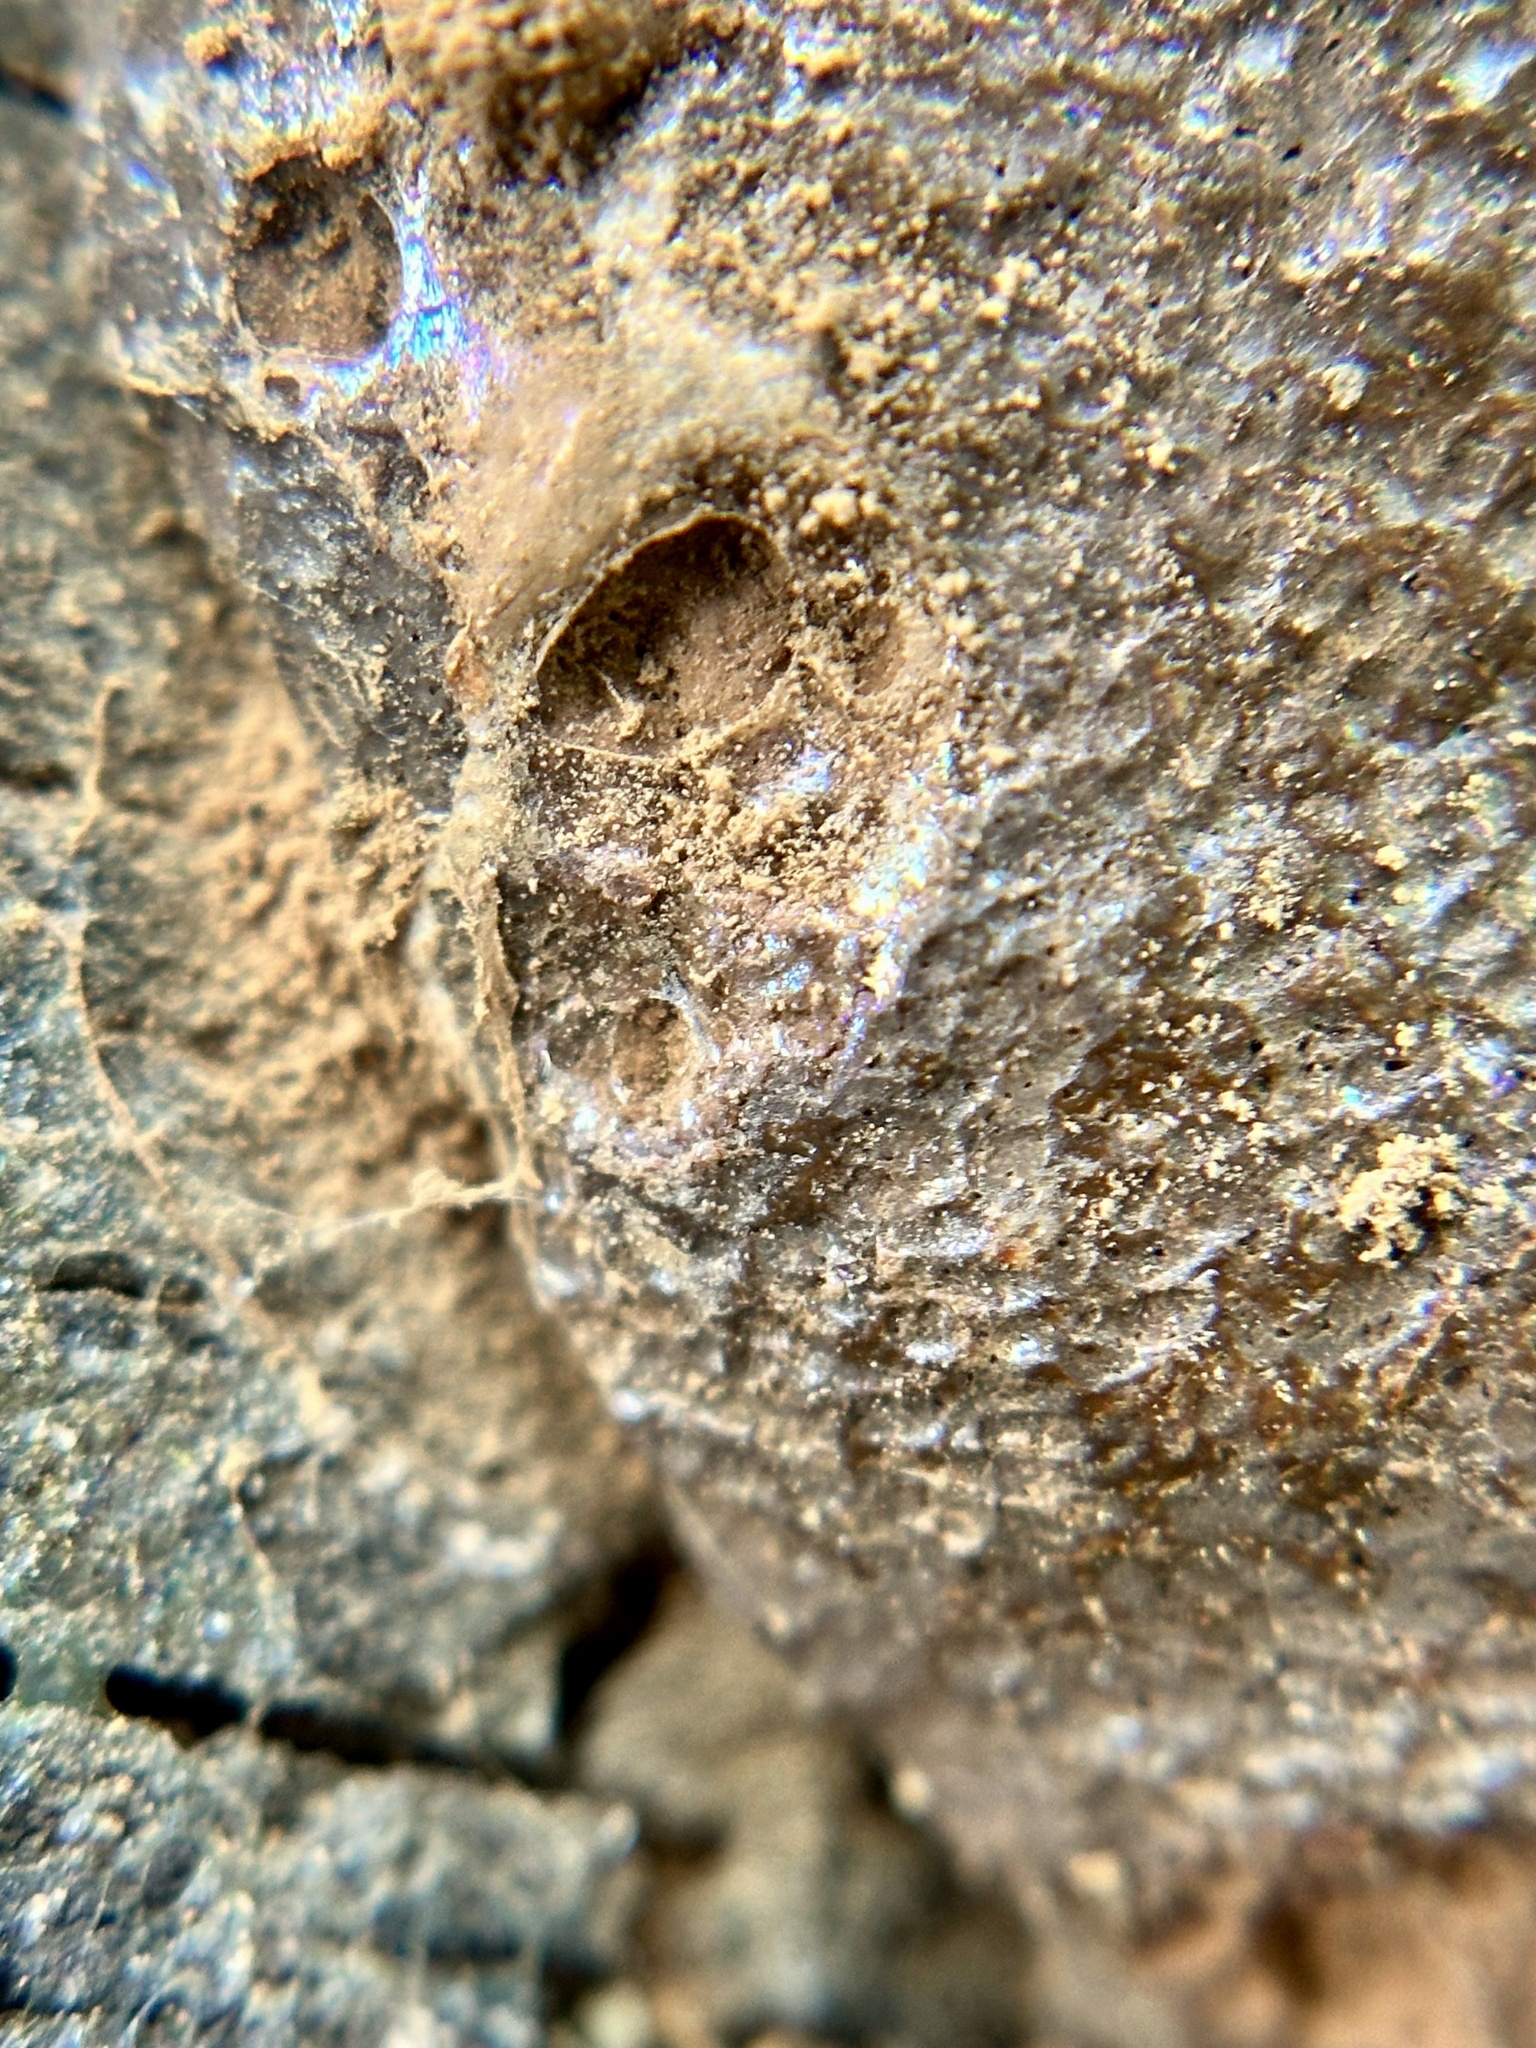

In [12]:
img = ImageOps.exif_transpose(img) #fixes orientation issues with some images
display(img)

In [13]:
w,h = img.size
print("Loaded:", img_path, "size:", (w, h))

Loaded: /gpfs_common/share03/ftrscape/image_dataset/obs_258568965_photo_463949088.jpg size: (1536, 2048)


In [14]:
# thresholds: adjust later
BOX_THRESHOLD = 0.20 #confidence threshold for bounding box predictions, higher means more confident but fewer boxes
TEXT_THRESHOLD = 0.15 #confidence threshold for text labels, higher means more confident but fewer labels assigned to each box

In [15]:
group_results = {}

for group_name, prompt in PROMPT_GROUPS.items():
    print(f"\nRunning detection for group: {group_name} with prompt: {prompt}")
    boxes, scores, labels = detect_one_prompt(img, prompt,BOX_THRESHOLD, TEXT_THRESHOLD)
    top =  float(scores.max()) if len(scores) > 0 else None
    print(f"{group_name:12s} - Detected {len(scores):3d} max score: {top}")
    group_results[group_name] = (boxes, scores, labels)


Running detection for group: vertebrates with prompt: animal. bird. mammal. fish. reptile. snake. lizard. turtle. amphibian. frog. toad. salamander. deer.


/usr/local/usrapps/ftrscape/snair3/env_AiPipeline/lib/python3.11/site-packages/transformers/models/grounding_dino/processing_grounding_dino.py:96: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


Detected boxes: 1
Raw detections: 1
vertebrates  - Detected   1 max score: 0.29471442103385925

Running detection for group: insects with prompt: insect. butterfly. moth. caterpillar. beetle. fly. mosquito. bee. wasp. ant. grasshopper. cricket. dragonfly. damselfly.
Detected boxes: 0
Raw detections: 0
insects      - Detected   0 max score: None

Running detection for group: arachnids with prompt: spider. scorpion. tick. mite.
Detected boxes: 0
Raw detections: 0
arachnids    - Detected   0 max score: None

Running detection for group: other_inverts with prompt: snail. slug. clam. mussel. oyster. octopus. squid. worm. crab. shrimp. lobster.
Detected boxes: 1
Raw detections: 1
other_inverts - Detected   1 max score: 0.2079319953918457

Running detection for group: plants_fungi with prompt: plant. leaf. flower. tree. grass. fern. moss. fungus. mushroom. lichen. algae. seaweed.
Detected boxes: 1
Raw detections: 1
plants_fungi - Detected   1 max score: 0.3040655851364136


In [16]:
#merge all detections into one list for visualization
all_boxes, all_scores, all_labels, all_group_names = [], [], [], []

for group_name, (boxes, scores, labels) in group_results.items():
    if len(scores) == 0:
        continue
    
    scores=np.asarray(scores).reshape(-1)
    if scores.size == 0: continue #if no scores, skip this group

    # some post processing to make sure the boxes are in the right format for visualization and merging
    boxes = np.asarray(boxes)  #convert to numpy array for easier manipulation
    if boxes.ndim == 1 and boxes.size == 4: #sometimes if only one box is detected, it might be returned as a 1D array instead of 2D, so we reshape it to ensure consistency
        boxes = boxes.reshape(1, 4)
    if boxes.ndim != 2 or boxes.shape[1] != 4: #check if the boxes are in the expected format (N, 4) where N is the number of boxes and 4 corresponds to the coordinates (x1, y1, x2, y2)
        print(f"Warning: boxes for group {group_name} have unexpected shape {boxes.shape} and dtype = {boxes.dtype}, skipping.")
        continue

    labels = np.asarray(labels).reshape(-1) #reshape to 1D array

    all_boxes.append(boxes)
    all_scores.append(scores)
    all_labels.append(labels)
    all_group_names.append(np.array([group_name]*scores.size))




In [17]:
if not all_scores:
    print("No detections found.")
else:
    boxes = np.concatenate(all_boxes, axis=0) 
    scores = np.concatenate(all_scores, axis=0)
    labels = np.concatenate(all_labels, axis=0)
    group_names = np.concatenate(all_group_names, axis=0)

    order = np.argsort(-scores) #sort by confidence score descending
    boxes = boxes[order]
    scores = scores[order]
    labels = labels[order]
    groups = group_names[order]

    print("Total Merged Detections:", len(scores))
    print("Top 5 Detections:")
    for i in range(min(5, len(scores))):
        print(f"Detection {i+1}: Label={labels[i]}, Score={scores[i]:.2f}, Group={groups[i]}")
    print("Top Score: ", float(scores[0]))

    

Total Merged Detections: 3
Top 5 Detections:
Detection 1: Label=plant fungus lichen, Score=0.30, Group=plants_fungi
Detection 2: Label=animal, Score=0.29, Group=vertebrates
Detection 3: Label=clam, Score=0.21, Group=other_inverts
Top Score:  0.3040655851364136


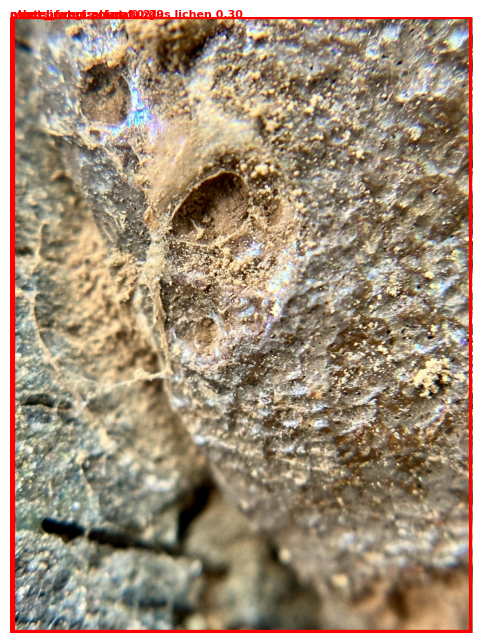

In [18]:
fig, ax = plt.subplots(1, figsize=(12, 8))
ax.imshow(img)

k = min(4, len(scores)) #only show top 2 detections for clarity, adjust as needed

for i in range(k):
    x0, y0, x1, y1 = boxes[i]
    score = scores[i]
    label = labels[i]
    group = groups[i]

    rect = patches.Rectangle((x0, y0), x1 - x0, y1 - y0, linewidth=3, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    ax.text(x0, max(0, y0-5), f"{group}:{label} {score:.2f}", fontsize=8, color='red', weight='bold')

ax.set_axis_off()
plt.show()
    

In [19]:
# for BOX_TH, TEXT_TH in [(0.20, 0.15), (0.15, 0.12), (0.12, 0.10), (0.10, 0.08)]:
#     total = 0
#     best = None
#     for gname, prompt in PROMPT_GROUPS.items():
#         _, s, _ = detect_one_prompt(img, prompt, BOX_TH, TEXT_TH)
#         total += len(s)
#         if len(s):
#             best = max(best or 0, float(s.max()))
#     print(f"BOX_TH={BOX_TH:.2f} TEXT_TH={TEXT_TH:.2f}  total_dets={total:3d}  best_score={best}")


# For all the images, get the bounding boxes

In [20]:

# images_dir = IMAGE_DATASET_DIR

# out_dir = OUTPUTS_DIR
# out_dir.mkdir(parents=True, exist_ok=True)

# csv_path = OUTPUTS_DIR / "sam_boxes_top4.csv"
# summary_path = OUTPUTS_DIR / "sam_boxes_summary.csv"

# img_paths = sorted([*images_dir.glob("*.jpg"), *images_dir.glob("*.jpeg"),
#                     *images_dir.glob("*.png"), *images_dir.glob("*.webp")])

# print("Found images:", len(img_paths))
# print("Reading from:", images_dir)
# print("Writing overlays to:", out_dir)
# print("Writing CSV:", csv_path)


In [21]:
# Use the HPC image dataset folder
images_dir = IMAGE_DATASET_DIR

out_dir = OUTPUTS_DIR
out_dir.mkdir(parents=True, exist_ok=True)

csv_path = OUTPUTS_DIR / "sam_boxes_top4.csv"
summary_path = OUTPUTS_DIR / "sam_boxes_summary.csv"

# Only process these images (WITHOUT extension)
selected_image_names = [
    "obs_10317797_photo_14298032",
    "obs_33435868_photo_52515163",
    "obs_64497720_photo_103704678",
    "obs_102691691_photo_171703626",
    "obs_130480768_photo_70327211",
    "obs_188731534_photo_330410184",
    "obs_194599339_photo_342107100",
    "obs_194795499_photo_341224314",
    "obs_195713651_photo_344383957",
    "obs_220102252_photo_389649357",
    "obs_220822650_photo_391000325",
    "obs_250956763_photo_448935283",
    "obs_256022699_photo_458927175",
    "obs_258568965_photo_463949088",
    "obs_263836670_photo_474047112",
    "obs_264953671_photo_475827468",
    "obs_291009479_photo_523542929",
    "obs_302755190_photo_545634287",
    "obs_318344322_photo_575337712",
    "obs_318533969_photo_575706140",
    "obs_319669394_photo_577875426",
    "obs_321389820_photo_581234419",
    "obs_323944435_photo_586236533",
    "obs_325267824_photo_588882003",
    "obs_325625055_photo_589595206",
    "obs_326876805_photo_592092171",
    "obs_327076113_photo_592488640",
    "obs_331752340_photo_601901044",
    "obs_331831594_photo_602051260",
    "obs_332241462_photo_602909620",
    "obs_333144263_photo_501540234",
    "obs_333664707_photo_605748155",
    "obs_334025380_photo_606497684",
    "obs_334758419_photo_607987821",
    "obs_336269939_photo_611037472",
    "obs_337063055_photo_612648507",
    "obs_337600645_photo_614526508",
    "obs_337606242_photo_613762919",
    "obs_337610708_photo_613769550",
    "obs_337610714_photo_613769638",
    "obs_338007030_photo_614585734",
    "obs_338486970_photo_615576074",
    "obs_339993526_photo_618618071",
    "obs_340263466_photo_619175705",
    "obs_340271186_photo_619190124",
    "obs_340304697_photo_619256274",
    "obs_340326193_photo_619295159",
    "obs_340326194_photo_619295158",
    "obs_340337296_photo_536341964",
    "obs_340337865_photo_533753896",
    "obs_340364592_photo_619375042",
    "obs_340368188_photo_619383348",
    "obs_340433312_photo_619519266",
    "obs_340514309_photo_619678757",
    "obs_340514310_photo_619679014",
    "obs_340542613_photo_619737737",
    "obs_340825934_photo_620308797",
    "obs_340848497_photo_620354560",
    "obs_340848514_photo_620354575",
    "obs_340848746_photo_620355031",
    "obs_341060278_photo_547585371",
    "obs_341067936_photo_620805844",
    "obs_341194952_photo_621071156",
]

selected_set = set(selected_image_names)

# Collect all candidate image files
all_img_paths = sorted([
    *images_dir.glob("*.jpg"),
    *images_dir.glob("*.jpeg"),
    *images_dir.glob("*.png"),
    *images_dir.glob("*.webp"),
])

# Map stem -> path
path_map = {p.stem: p for p in all_img_paths}

# Keep only requested images, in the SAME order as your list
img_paths = [path_map[name] for name in selected_image_names if name in path_map]

# Optional: report missing files
missing = [name for name in selected_image_names if name not in path_map]

print("Requested images:", len(selected_image_names))
print("Found requested images:", len(img_paths))
print("Missing images:", len(missing))
if missing:
    print("Missing names:")
    for m in missing:
        print("  ", m)

print("Reading from:", images_dir)
print("Writing overlays to:", out_dir)
print("Writing CSV:", csv_path)

Requested images: 63
Found requested images: 63
Missing images: 0
Reading from: /gpfs_common/share03/ftrscape/image_dataset
Writing overlays to: /gpfs_common/share03/ftrscape/snair3/wew_notebooks/outputs_gd
Writing CSV: /gpfs_common/share03/ftrscape/snair3/wew_notebooks/outputs_gd/sam_boxes_top4.csv


In [22]:
rows = []
summary_rows = []

TOP_K = 5

for img_path in img_paths:
    img = Image.open(img_path).convert("RGB")
    img= ImageOps.exif_transpose(img)

    boxes, scores, labels, groups = detect_multi_pass(img)

    k = min(TOP_K, len(scores))

    top_score = float(scores[0]) if len(scores) else None

    fig,ax = plt.subplots(1, figsize=(12,8))
    ax.imshow(img)

    if k ==0:
        ax.text(10,20, "No Detections", fontsize = 14, color = "red", weight = "bold")
    else:
        for rank in range(k):
            x0, y0, x1, y1 = boxes[rank]
            score = scores[rank]
            label = labels[rank]
            group = groups[rank]

            rect = patches.Rectangle((x0, y0), x1 - x0, y1 - y0, linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            ax.text(x0, max(0, y0-5), f"{group}:{label} {score:.2f}", fontsize=8, color='red', weight='bold')
            
            rows.append({
                "image": img_path.name,
                "rank": rank+1,
                "score" :float(score),
                "group": str(group),
                "label": str(label),
                "x0" : float(x0),
                "y0" : float(y0),
                "x1": float(x1),
                "y1": float(y1)


            })
    ax.set_axis_off()
    save_path = out_dir/f"{img_path.stem}.jpg"

    plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.close(fig)

    summary_rows.append({
        "image": img_path.name,
        "n_boxes": int(k),
        "top_score":top_score,
        "overlay":str(save_path)
    })

Detected boxes: 1
Raw detections: 1
Detected boxes: 0
Raw detections: 0
Detected boxes: 0
Raw detections: 0
Detected boxes: 0
Raw detections: 0
Detected boxes: 0
Raw detections: 0


/usr/local/usrapps/ftrscape/snair3/env_AiPipeline/lib/python3.11/site-packages/transformers/models/grounding_dino/processing_grounding_dino.py:96: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


Detected boxes: 5
Raw detections: 5
Detected boxes: 2
Raw detections: 2
Detected boxes: 2
Raw detections: 2
Detected boxes: 2
Raw detections: 2
Detected boxes: 1
Raw detections: 1


/usr/local/usrapps/ftrscape/snair3/env_AiPipeline/lib/python3.11/site-packages/transformers/models/grounding_dino/processing_grounding_dino.py:96: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


Detected boxes: 2
Raw detections: 2
Detected boxes: 0
Raw detections: 0
Detected boxes: 0
Raw detections: 0
Detected boxes: 0
Raw detections: 0
Detected boxes: 0
Raw detections: 0


...

Detected boxes: 0
Raw detections: 0
Detected boxes: 3
Raw detections: 3
Detected boxes: 0
Raw detections: 0
Detected boxes: 0
Raw detections: 0
Detected boxes: 20
Raw detections: 20


/usr/local/usrapps/ftrscape/snair3/env_AiPipeline/lib/python3.11/site-packages/transformers/models/grounding_dino/processing_grounding_dino.py:96: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


Detected boxes: 0
Raw detections: 0
Detected boxes: 4
Raw detections: 4
Detected boxes: 0
Raw detections: 0
Detected boxes: 0
Raw detections: 0
Detected boxes: 8
Raw detections: 8


/usr/local/usrapps/ftrscape/snair3/env_AiPipeline/lib/python3.11/site-packages/transformers/models/grounding_dino/processing_grounding_dino.py:96: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


Detected boxes: 1
Raw detections: 1
Detected boxes: 0
Raw detections: 0
Detected boxes: 0
Raw detections: 0
Detected boxes: 0
Raw detections: 0
Detected boxes: 4
Raw detections: 4


In [23]:
pd.DataFrame(rows).to_csv(csv_path, index=False) 
pd.DataFrame(summary_rows).to_csv(summary_path, index=False)

print("Saved overlays to: ", out_dir)
print("Saved SAM Boxes CSV to :",csv_path)
print("Saved summary CSV to :", summary_path)


Saved overlays to:  /gpfs_common/share03/ftrscape/snair3/wew_notebooks/outputs_gd
Saved SAM Boxes CSV to : /gpfs_common/share03/ftrscape/snair3/wew_notebooks/outputs_gd/sam_boxes_top4.csv
Saved summary CSV to : /gpfs_common/share03/ftrscape/snair3/wew_notebooks/outputs_gd/sam_boxes_summary.csv
